In [5]:
import pandas as pd

df = pd.read_excel('data/table/BasedeDatosTransectosJoseLuis.xlsx')
df.head()

,Transecto,Ageb Manzana,Sexo,Edad,Escolaridad,¿Cuántos años tiene viviendo en este lugar?,¿Cuántas personas viven en este hogar?,¿Cuántas de esas personas….? | Tienen 18 años o más,¿Cuántas de esas personas….? | Aportan económicamente al hogar,¿Cuántas de esas personas….? | Cuentan con un trabajo remunerado que requiera más de 20 horas a la semana,...,¿Qué aspectos de la vida cotidiana considera que volverán a ser como antes de la pandemia? | Clases presenciales,¿Qué aspectos de la vida cotidiana considera que volverán a ser como antes de la pandemia? | Todo es igual que antes,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso de gel antibacterial,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso de cubrebocas en caso de enfermedades contagiosas,"¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Curso, conferencia o reuniones en línea",¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Campañas de vacunación,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso y/o venta de productos sanitizantes,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Venta o entregas a domicilio,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Chat de ventas o vecinales,Ponderador
0,7,1410100011395030,Mujeres,45-54,Preparatoria completa,7,2,2,1,9+,...,No,No,Sí,Sí,No,No,No,Sí,No,189
1,6,1403900013904010,Mujeres,65 y +,Primaria incompleta,25,2,2,1,1,...,No,Sí,Sí,Sí,No,No,Sí,No,No,414
2,6,1403900013904010,Hombres,65 y +,Primaria completa,4,1,1,1,0,...,No,Sí,Sí,No,No,No,No,No,No,414
3,1,1409800011434010,Mujeres,35-44,Secundaria completa,30+,4,3,1,1,...,No,Sí,No,Sí,No,No,No,No,No,742
4,6,1403900013904010,Hombres,35-44,Licenciatura completa,30+,4,4,4,4,...,No,Sí,Sí,No,No,No,No,No,No,414


In [2]:
for col in df.columns:
    print(f"Columna: {col}")
    print(f"  Tipo: {df[col].dtype}")
    print(f"  Opciones únicas: {df[col].unique()}\n")

Columna: Transecto
  Tipo: int64
  Opciones únicas: [7 6 1 3 2 5 4]

Columna: Ageb Manzana
  Tipo: object
  Opciones únicas: [1410100011395030 1403900013904010 1409800011434010 1403900014103000
 1410100011395020 1410100010984010 1403900013904020 '141010001108A022'
 1403900014103010 1403900014156000 '141010001108A010' 1410100010984000
 1409800011434020 1410100011075030 1403900010327010 1403900014156040
 1403900010191020 1410100010999050 1403900010327000 1410100010999030
 1409800012254000 1403900010990010 1410100011446010 1409800012254010
 1409800012606000 1403900010223020 1409800010370020 1412000012609010
 1409800012606010 1409800011260010 1403900010223010 1410100011075020
 1412000012609020 1410100011431000 1409800011260020 1410100011431010
 1403900010191010 1412000012632000 1412000012524000 1412000012632010
 1412000012670000 1409800010474030 1412000012524020 1410100011408000
 1410100011408010 1409800012610000 1409800010296010 1403900010204000
 1403900010473020 1412000010265000 14098000

In [3]:
import pandas as pd
import numpy as np

# Suponiendo que tu DataFrame se llama df

column_info = []

for col in df.columns:
    dtype = df[col].dtype
    unique_vals = df[col].dropna().unique()
    n_unique = len(unique_vals)
    n_null = df[col].isnull().sum()
    suggestion = ""

    # Sugerencia de tratamiento
    if np.issubdtype(dtype, np.number):
        suggestion = "Numérica continua, estandarizar/normalizar + imputar NaN si hay"
    elif dtype == 'object':
        if n_unique == 2:
            suggestion = "Binaria, aplicar one-hot encoding"
        else:
            suggestion = "Categoría nominal u ordinal, aplicar label encoding"
    else:
        suggestion = "Revisar manualmente"

    column_info.append({
        "Columna": col,
        "Tipo": str(dtype),
        "N Unique": n_unique,
        "N Null": n_null,
        "Sugerencia": suggestion,
        "Valores únicos": unique_vals
    })

# Convertir a DataFrame para ver todo
info_df = pd.DataFrame(column_info)
pd.set_option('display.max_rows', None)
info_df

,Columna,Tipo,N Unique,N Null,Sugerencia,Valores únicos
0,Transecto,int64,7,0,"Numérica continua, estandarizar/normalizar + i...","[7, 6, 1, 3, 2, 5, 4]"
1,Ageb Manzana,object,295,0,"Categoría nominal u ordinal, aplicar label enc...","[1410100011395030, 1403900013904010, 140980001..."
2,Sexo,object,2,0,"Binaria, aplicar one-hot encoding","[Mujeres, Hombres]"
3,Edad,object,6,0,"Categoría nominal u ordinal, aplicar label enc...","[45-54, 65 y +, 35-44, 25-34, 55-64, 18-24]"
4,Escolaridad,object,15,0,"Categoría nominal u ordinal, aplicar label enc...","[Preparatoria completa, Primaria incompleta, P..."
5,¿Cuántos años tiene viviendo en este lugar?,object,27,0,"Categoría nominal u ordinal, aplicar label enc...","[7, 25, 4, 30+, 6, 24, 22, 5, 10, 15, 8, 16, 2..."
6,¿Cuántas personas viven en este hogar?,object,9,0,"Categoría nominal u ordinal, aplicar label enc...","[2, 1, 4, 5, 3, 8, 6, 9+, 7]"
7,¿Cuántas de esas personas….? | Tienen 18 años ...,object,10,0,"Categoría nominal u ordinal, aplicar label enc...","[2, 1, 3, 4, 5, 6, 9+, 7, 8, 0]"
8,¿Cuántas de esas personas….? | Aportan económi...,object,10,0,"Categoría nominal u ordinal, aplicar label enc...","[1, 4, 5, 2, 3, 0, 6, 9+, 7, 8]"
9,¿Cuántas de esas personas….? | Cuentan con un ...,object,10,0,"Categoría nominal u ordinal, aplicar label enc...","[9+, 1, 0, 4, 5, 2, 3, 6, 8, 7]"


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def regression_data_handler(df, exclude_cols=None, invalid_values=None, ordinal_mappings=None):
    """
    Prepara datos para regresión:
    - Variables continuas → imputar NaN
    - Variables binarias → 0/1
    - Variables ordinales → label encoding
    - Variables nominales → label encoding
    - Columnas tipo '9+', '35+', etc. → convertidas a numéricas si hay más de 5 numéricas
    - NO se estandariza ninguna variable
    """
    df_processed = df.copy()
    if exclude_cols is None:
        exclude_cols = []
    if invalid_values is None:
        invalid_values = []
    if ordinal_mappings is None:
        ordinal_mappings = {}

    mappings = {"ordinal": {}, "binary": {}, "nominal": {}}

    num_numeric_cols = df_processed.select_dtypes(include=np.number).shape[1]

    for col in df_processed.columns:
        if col in exclude_cols:
            continue

        # Limpiar valores inválidos
        df_processed[col] = df_processed[col].replace(invalid_values, np.nan)

        unique_vals = df_processed[col].dropna().unique()
        n_unique = len(unique_vals)
        dtype = df_processed[col].dtype

        # ===== Regla especial: objetos tipo '9+', '35+', etc. =====
        if dtype == 'object' and num_numeric_cols >= 3:
            try:
                df_processed[col] = df_processed[col].astype(str).str.replace(r'\+', '', regex=True).astype(float)
                # Imputar NaN con mediana
                if df_processed[col].dropna().shape[0] > 0:
                    df_processed[col] = df_processed[col].fillna(df_processed[col].median())
                else:
                    df_processed = df_processed.drop(columns=[col])
                continue
            except:
                pass  # si falla, sigue al tratamiento normal

        # ===== Ordinal =====
        if col in ordinal_mappings:
            le = LabelEncoder()
            le.fit(ordinal_mappings[col])
            df_processed[col] = le.transform(df_processed[col])
            mappings["ordinal"][col] = dict(zip(le.classes_, le.transform(le.classes_)))

        # ===== Binaria =====
        elif n_unique == 2:
            df_processed[col] = df_processed[col].apply(lambda x: 0 if x == unique_vals[0] else 1)
            mappings["binary"][col] = {unique_vals[0]: 0, unique_vals[1]: 1}

        # ===== Numérica continua =====
        elif np.issubdtype(dtype, np.number):
            if df_processed[col].dropna().shape[0] > 0:
                df_processed[col] = df_processed[col].fillna(df_processed[col].median())
            else:
                df_processed = df_processed.drop(columns=[col])

        # ===== Nominal =====
        else:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            mappings["nominal"][col] = dict(zip(le.classes_, le.transform(le.classes_)))

    # Eliminar columnas que quedaron sin varianza
    df_processed = df_processed.loc[:, df_processed.nunique() > 1]

    return df_processed, mappings

In [7]:
import script.lib as lib

exclude_cols = None
invalid_values = [9999999, 999999]
ordinal_mappings = None

df_processed, mappings = regression_data_handler(
    df,
    exclude_cols=exclude_cols,
    invalid_values=invalid_values,
    ordinal_mappings=ordinal_mappings
)

In [8]:
df_processed.head()

,Transecto,Ageb Manzana,Sexo,Edad,Escolaridad,¿Cuántos años tiene viviendo en este lugar?,¿Cuántas personas viven en este hogar?,¿Cuántas de esas personas….? | Tienen 18 años o más,¿Cuántas de esas personas….? | Aportan económicamente al hogar,¿Cuántas de esas personas….? | Cuentan con un trabajo remunerado que requiera más de 20 horas a la semana,...,¿Qué aspectos de la vida cotidiana considera que volverán a ser como antes de la pandemia? | Clases presenciales,¿Qué aspectos de la vida cotidiana considera que volverán a ser como antes de la pandemia? | Todo es igual que antes,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso de gel antibacterial,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso de cubrebocas en caso de enfermedades contagiosas,"¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Curso, conferencia o reuniones en línea",¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Campañas de vacunación,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso y/o venta de productos sanitizantes,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Venta o entregas a domicilio,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Chat de ventas o vecinales,Ponderador
0,7,199,0,3,8,7.0,2.0,2.0,1.0,9.0,...,0,0,0,0,0,0,0,0,0,189
1,6,53,0,5,11,25.0,2.0,2.0,1.0,1.0,...,0,1,0,0,0,0,1,1,0,414
2,6,53,1,5,10,4.0,1.0,1.0,1.0,0.0,...,0,1,0,1,0,0,0,1,0,414
3,1,153,0,2,12,30.0,4.0,3.0,1.0,1.0,...,0,1,1,0,0,0,0,1,0,742
4,6,53,1,2,4,30.0,4.0,4.0,4.0,4.0,...,0,1,0,1,0,0,0,1,0,414


In [9]:
for col in df_processed.columns:
    print(f"Columna: {col}")
    print(f"  Tipo: {df_processed[col].dtype}")
    print(f"  Opciones únicas: {df_processed[col].unique()}\n")

Columna: Transecto
  Tipo: int64
  Opciones únicas: [7 6 1 3 2 5 4]

Columna: Ageb Manzana
  Tipo: int64
  Opciones únicas: [199  53 153  60 198 189  54 195  61  62 194 188 154 193   8  63   3 191
   7 190 167  16 204 168 171   6 145 245 172 149   5 192 246 202 150 203
   2 247 243 248 250 146 244 200 201 173 143   4  12 227 147 228 144 164
 251 158  10 174 157  99  97 163 267   9 266 276 155 277 156  20  21  98
  11 264  88 265  74 289  87 290  52 272  86 273  73  89 287 249  23  84
 253  22 288  40  85  15  25  42  82  24 252  50  83  34  19  51  41 269
  33  26  29 268  28  39 286  27  31  32 141 142  56 152  67  38 151  66
  44 262  43  37  65 263  57  64  55  36  80 166  81 165  35  93 176  69
 175  75  70  49  30  76  71  72 124  48  79  92 125  94 181 122  95  96
 123 121 160 241  47 148 184  91 159 185  90 187 162 242 197 100 101 186
 233 103 234 102 137 138 161 260  45 214 261 177  46 215 240  78  77 239
 180 216 178 217 231 179 257 140 139 256 259 258 232 127 275 274  58 183


In [21]:
df_processed = df_processed.drop(columns=['Transecto', 'Ponderador'])

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

target = '¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Luz'
# Filtrar outliers en la variable objetivo
df_filtered = df_processed[df_processed[target] <= 9999].copy()

# Separar X e y
X = df_filtered.drop(columns=[target])
y = df_filtered[target]

# 1️⃣ Selección de variables por correlación con la variable objetivo
correlations = X.corrwith(y).abs()
top_features = correlations.sort_values(ascending=False).head(20).index  # top 20 más correlacionadas
X = X[top_features]

# 2️⃣ Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3️⃣ Escalar variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ Entrenar Ridge Regression
ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)

# 5️⃣ Predicciones
y_train_pred = ridge.predict(X_train_scaled)
y_test_pred = ridge.predict(X_test_scaled)

# 6️⃣ Métricas
metrics_train = {
    'r2': r2_score(y_train, y_train_pred),
    'rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
    'mae': mean_absolute_error(y_train, y_train_pred)
}

metrics_test = {
    'r2': r2_score(y_test, y_test_pred),
    'rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
    'mae': mean_absolute_error(y_test, y_test_pred)
}

print("=== Métricas de Entrenamiento ===")
print(metrics_train)
print("\n=== Métricas de Prueba ===")
print(metrics_test)

# 7️⃣ Coeficientes interpretables
coef_df = pd.DataFrame({
    'Variable': top_features,
    'Coeficiente': ridge.coef_
}).sort_values(by='Coeficiente', key=abs, ascending=False)

print("\n=== Coeficientes Interpretables ===")
print(coef_df)

=== Métricas de Entrenamiento ===
{'r2': 0.2771194280356146, 'rmse': np.float64(228.25719575859875), 'mae': 146.92906709564653}

=== Métricas de Prueba ===
{'r2': 0.379998472733032, 'rmse': np.float64(191.32413677565256), 'mae': 138.77053456906117}

=== Coeficientes Interpretables ===
                                             Variable  Coeficiente
1   Durante la pandemia, ¿Cuál de los siguientes a...    46.253203
0                                          Ponderador    44.007843
6   ¿En qué mes del año utiliza los ventiladores o...    34.904121
3   ¿Cuáles de las siguientes actividades que real...    33.713584
14  ¿De acuerdo a su percepción, cuáles de las sig...    31.663708
10  ¿Qué aspectos de la vida cotidiana considera q...    28.584219
15  ¿Cuántas de esas personas….? | Tienen 18 años ...    28.541151
9   Indica la cantidad de ventiladores y/o aparato...   -26.331006
2   ¿Cuáles de las siguientes actividades que real...   -24.481591
7   ¿Considera que en su barrio o colonia la

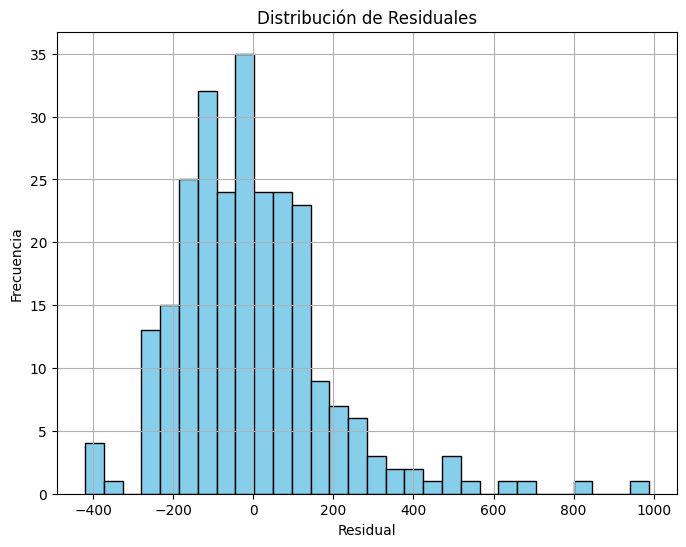

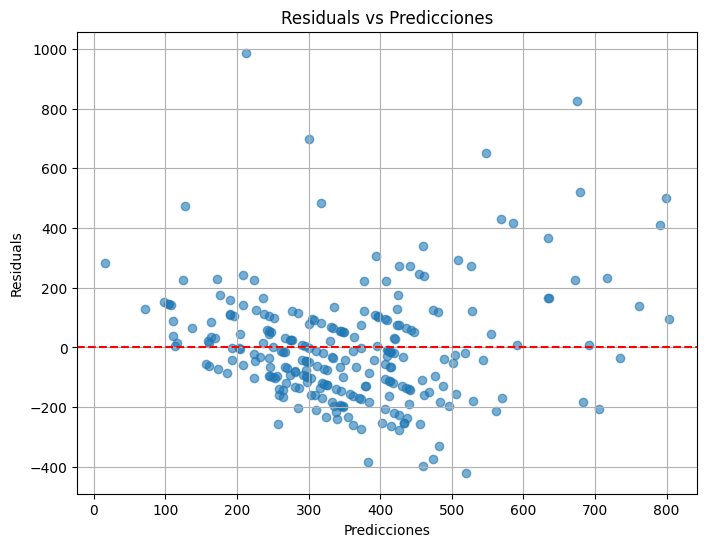

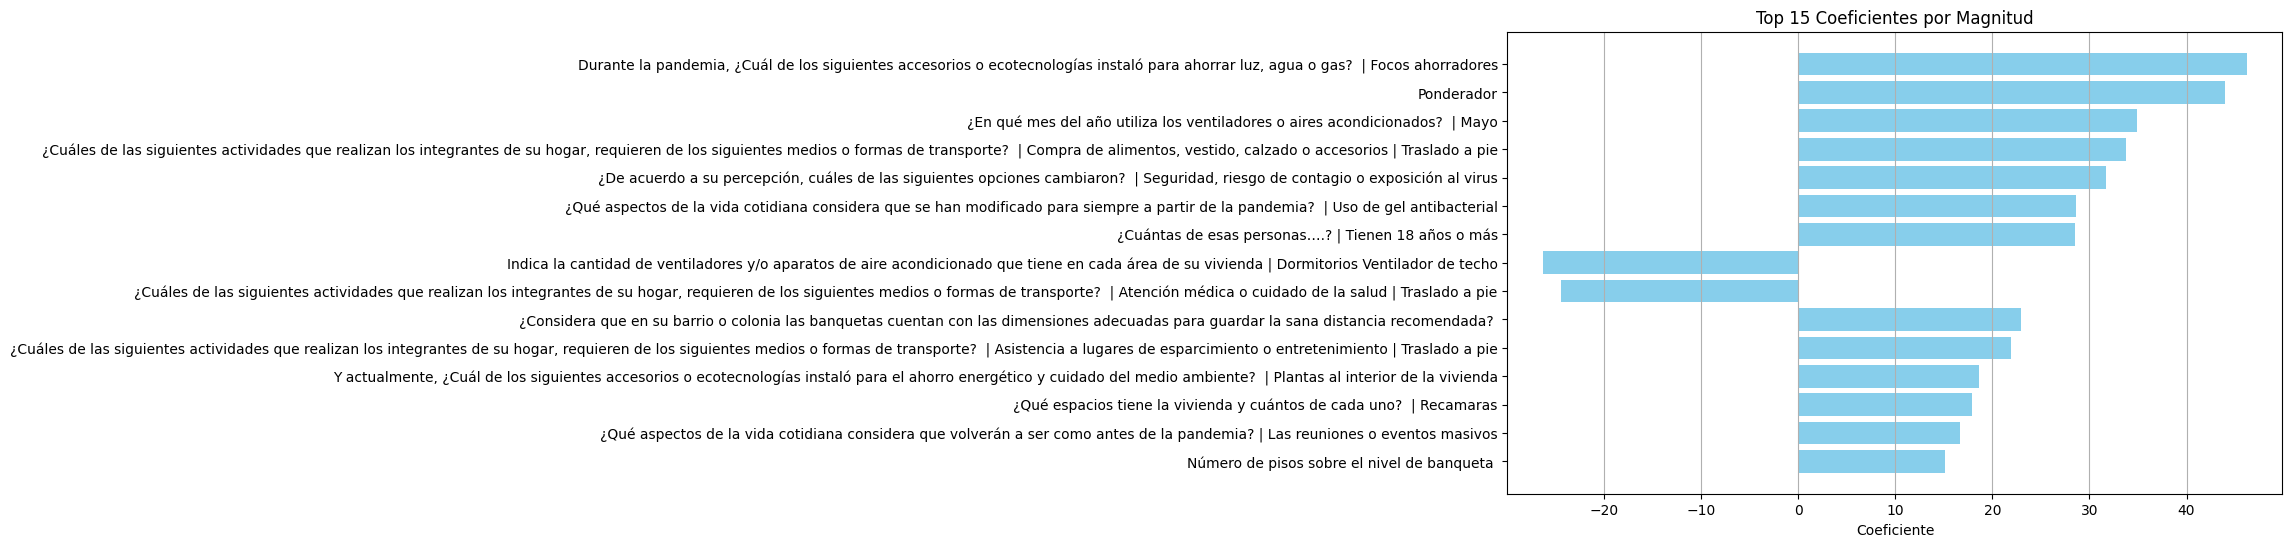

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

# 2️⃣ Residuales
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuales')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicciones')
plt.grid(True)
plt.show()

# 3️⃣ Coeficientes más importantes
coef_df_sorted = coef_df.sort_values(by='Coeficiente', key=abs, ascending=False).head(15)
plt.figure(figsize=(10,6))
plt.barh(coef_df_sorted['Variable'], coef_df_sorted['Coeficiente'], color='skyblue')
plt.xlabel('Coeficiente')
plt.title('Top 15 Coeficientes por Magnitud')
plt.gca().invert_yaxis()  # la variable más importante arriba
plt.grid(axis='x')
plt.show()

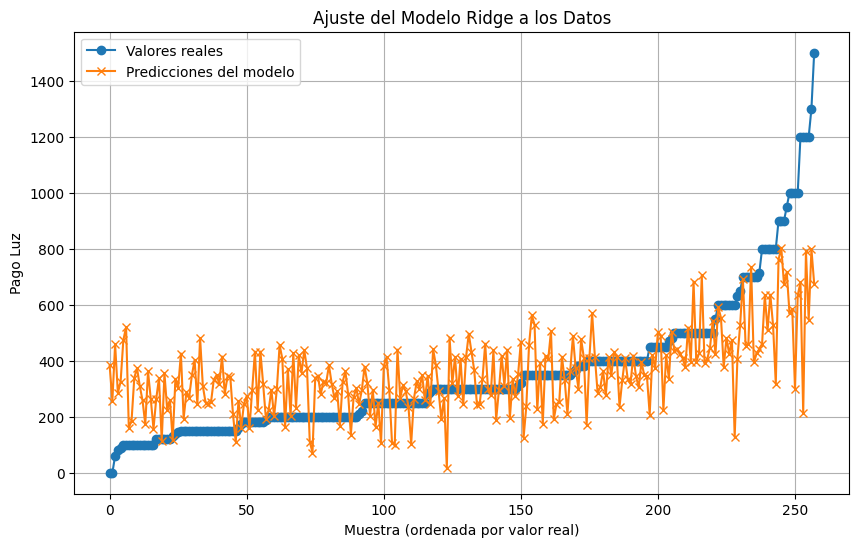

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenar los valores reales para la visualización
sorted_idx = np.argsort(y_test)
y_test_sorted = np.array(y_test)[sorted_idx]
y_pred_sorted = np.array(y_test_pred)[sorted_idx]

plt.figure(figsize=(10,6))
plt.plot(y_test_sorted, label='Valores reales', marker='o')
plt.plot(y_pred_sorted, label='Predicciones del modelo', marker='x')
plt.xlabel('Muestra (ordenada por valor real)')
plt.ylabel('Pago Luz')
plt.title('Ajuste del Modelo Ridge a los Datos')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
pd.set_option('display.max_colwidth', None)  # muestra toda la columna completa
pd.set_option('display.max_rows', None)      # muestra todas las filas

In [30]:
import pandas as pd

# Crear DataFrame con coeficientes
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': ridge.coef_
}).sort_values(by='Coeficiente', key=abs, ascending=False)

print("=== Coeficientes del Modelo Ridge ===")
print(coef_df)

=== Coeficientes del Modelo Ridge ===
                                                                                                                                                                                                                  Variable  \
0                                                                                      Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Focos ahorradores   
19                                                                                                              ¿Ha tenido conocimiento de algún hecho violento dentro del perímetro de su manzana en los últimos 3 años?    
5                                                                                                                                             ¿En qué mes del año utiliza los ventiladores o aires acondicionados?  | Mayo   
13                                                                        